# Baseline: Regressão Logística

> Objetivo: treinar um modelo simples de regressão logística e avaliar desempenho no conjunto de teste.

## 1) Importação e leitura dos dados

In [1]:
# importações de bibliotecas
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support
    )
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ortho_clean = pd.read_csv('ortho_eda_clean.csv')

## 2) Preparação dos dados

In [2]:
# Definir preditores/target
X = ortho_clean.drop('mudanca_CPAK', axis=1)
y = ortho_clean['mudanca_CPAK']

# One-Hot Encoding como temos variáveis categóricas, codificamos antes de todos os testes/modelos
cols_ohe = [c for c in ['Grupo_pre', 'Sexo'] if c in X.columns]
X = pd.get_dummies(X, columns=cols_ohe, drop_first=True)

# Alias opcional para inspeção rápida
X_ohe = X.copy()

# Split estratificado dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [3]:
X_ohe.head()

,Idade,Peso,Altura_cm,IMC,Fle_0,EVA_0,PM6_0,WD_0,WR_0,WAtotal_0,WT_0,Grupo_pre_2,Grupo_pre_3,Grupo_pre_4,Grupo_pre_5,Grupo_pre_6,Grupo_pre_7,Grupo_pre_8,Grupo_pre_9,Sexo_1
0,67,80.0,158.0,32.046146,86.0,4.0,324.0,15,6.0,54.0,75,False,False,False,True,False,False,False,False,False
1,76,60.0,155.0,24.973985,90.0,4.0,357.0,14,7.0,39.0,60,False,False,False,True,False,False,False,False,True
2,72,93.0,182.0,28.076319,45.0,10.0,289.0,15,4.0,53.0,72,False,False,False,False,False,False,False,False,True
3,67,71.0,163.0,26.722873,127.0,2.0,390.0,1,1.0,16.0,18,False,False,False,False,True,False,False,False,True
4,66,49.0,160.0,19.140625,120.0,0.0,285.0,0,0.0,8.0,8,False,False,False,False,True,False,False,False,False


## 3) Regressão logistica: baseline

In [4]:
# Treino do baseline com Regressão Logística
clf_LR = LogisticRegression(random_state=42)
clf_LR = clf_LR.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_LR = clf_LR.predict(X_test)
y_pred_LR_prob = clf_LR.predict_proba(X_test)
print(y_pred_LR_prob)
print(y_pred_LR)

[[9.94280849e-01 5.71915082e-03]
 [9.95761608e-01 4.23839168e-03]
 [9.99799616e-01 2.00383568e-04]
 [9.64181033e-01 3.58189674e-02]
 [9.93979748e-01 6.02025181e-03]
 [9.92111223e-01 7.88877662e-03]
 [9.61981518e-01 3.80184821e-02]
 [9.96239500e-01 3.76049980e-03]
 [2.37091161e-01 7.62908839e-01]
 [8.40136888e-01 1.59863112e-01]
 [9.99692221e-01 3.07779428e-04]
 [8.77927885e-01 1.22072115e-01]
 [9.95861054e-01 4.13894628e-03]
 [9.99426162e-01 5.73838361e-04]
 [9.98069354e-01 1.93064622e-03]
 [9.97777568e-01 2.22243161e-03]
 [8.73780693e-01 1.26219307e-01]
 [9.93804256e-01 6.19574424e-03]
 [9.99987188e-01 1.28119849e-05]
 [9.99085768e-01 9.14232412e-04]
 [9.74398693e-01 2.56013074e-02]
 [9.99950168e-01 4.98318073e-05]
 [5.67166074e-01 4.32833926e-01]
 [9.83084319e-01 1.69156806e-02]
 [9.40510352e-01 5.94896483e-02]
 [9.95393647e-01 4.60635323e-03]
 [9.85869253e-01 1.41307469e-02]
 [9.96991343e-01 3.00865712e-03]
 [9.87920528e-01 1.20794723e-02]
 [2.19381638e-01 7.80618362e-01]
 [9.265353

c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 3.1) Avaliação do modelo

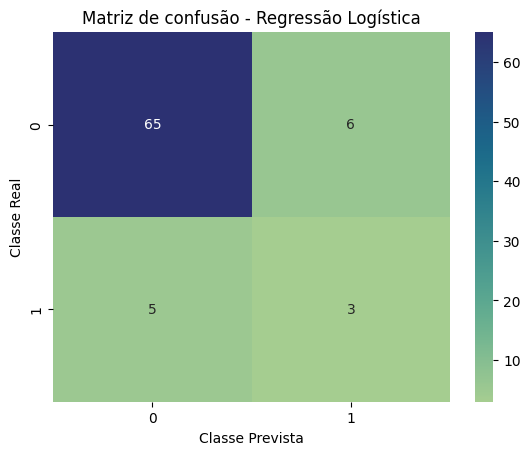

In [5]:
# Matriz de confusão do baseline (Regressão Logística)
c_matrix_LR = confusion_matrix(y_test, y_pred_LR)

# Visualização da matriz de confusão
sns.heatmap(c_matrix_LR, annot=True, fmt='d', cmap='crest')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')

plt.title('Matriz de confusão - Regressão Logística')
plt.show()

In [6]:
# Relatório de classificação do baseline
print(classification_report(y_test, y_pred_LR))

# Área sob a curva ROC (AUC)
auc = roc_auc_score(y_test, y_pred_LR)
print('AUC:', auc)

              precision    recall  f1-score   support

           0       0.93      0.92      0.92        71
           1       0.33      0.38      0.35         8

    accuracy                           0.86        79
   macro avg       0.63      0.65      0.64        79
weighted avg       0.87      0.86      0.86        79

AUC: 0.6452464788732395


In [7]:
# Validação cruzada (Stratified K-fold) para estimar generalização
pred_cross_LR = cross_val_predict(
    clf_LR,
    X,
    y,
    cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 )
print(classification_report(y, pred_cross_LR, digits=4))




              precision    recall  f1-score   support

           0     0.9032    0.9492    0.9256       236
           1     0.1429    0.0769    0.1000        26

    accuracy                         0.8626       262
   macro avg     0.5230    0.5130    0.5128       262
weighted avg     0.8278    0.8626    0.8437       262



c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

In [8]:
coeficientes_lr = pd.DataFrame({
    'Variavel': X_train.columns,
    'Coeficiente': clf_LR.coef_[0]
})

coeficientes_lr['Abs_Coeficiente'] = coeficientes_lr['Coeficiente'].abs()
coeficientes_lr.sort_values(by='Abs_Coeficiente', ascending=False)

,Variavel,Coeficiente,Abs_Coeficiente
14,Grupo_pre_5,0.480503,0.480503
11,Grupo_pre_2,0.475860,0.475860
12,Grupo_pre_3,-0.436021,0.436021
13,Grupo_pre_4,-0.391907,0.391907
8,WR_0,0.192981,0.192981
3,IMC,-0.162843,0.162843
7,WD_0,-0.151686,0.151686
0,Idade,-0.108729,0.108729
16,Grupo_pre_7,-0.104127,0.104127
5,EVA_0,0.103426,0.103426


## 4) Teste simples de hipoteses:
Nesta secção avaliamos se algumas variáveis estão a representar a mesma informação e se podem ser removidas sem perda relevante de desempenho.

- Comparação 1: WT_0 versus os seus componentes (WR_0, WD_0 e WAtotal_0)
- Comparação 2: IMC versus variáveis de base (Peso e Altura_cm)

Objetivo: identificar a forma mais simples de representar os dados, reduzindo redundância e mantendo qualidade preditiva.



# 4.1 Comparação 1: WT_0 versus os seus componentes (WR_0, WD_0 e WAtotal_0)

In [9]:
# Remover WT_0 dos dados de treino e teste
col_wt0 = 'WT_0'

if col_wt0 in X_train.columns and col_wt0 in X_test.columns:
    X_train_sem_wt = X_train.drop(columns=[col_wt0])
    X_test_sem_wt = X_test.drop(columns=[col_wt0])

    # Treinar modelo sem WT_0
    clf_LR_sem_wt = LogisticRegression(random_state=42, max_iter=2000)
    clf_LR_sem_wt = clf_LR_sem_wt.fit(X_train_sem_wt, y_train)

    # Previsões
    y_pred_LR_sem_wt = clf_LR_sem_wt.predict(X_test_sem_wt)

    # Stratified K-fold (sem WT_0)
    X_sem_wt_cv = X.drop(columns=[col_wt0])
    cv_sem_wt = sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pred_cross_sem_wt = cross_val_predict(
        LogisticRegression(random_state=42, max_iter=2000),
        X_sem_wt_cv,
        y,
        cv=cv_sem_wt
    )
else:
    print("WT_0 não foi encontrada em X_train/X_test.")

c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please

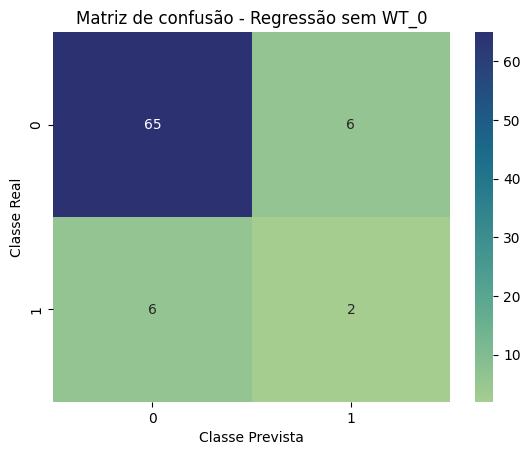

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        71
           1       0.25      0.25      0.25         8

    accuracy                           0.85        79
   macro avg       0.58      0.58      0.58        79
weighted avg       0.85      0.85      0.85        79

AUC sem WT_0: 0.5827464788732394
=== Stratified K-fold (sem WT_0) ===
              precision    recall  f1-score   support

           0     0.9143    0.9492    0.9314       236
           1     0.2941    0.1923    0.2326        26

    accuracy                         0.8740       262
   macro avg     0.6042    0.5707    0.5820       262
weighted avg     0.8527    0.8740    0.8620       262



In [10]:
# Avaliação do modelo sem WT_0
if col_wt0 in X_train.columns and col_wt0 in X_test.columns:
    confusion_sem_wt = confusion_matrix(y_test, y_pred_LR_sem_wt)
    sns.heatmap(confusion_sem_wt, annot=True, fmt='d', cmap='crest')
    plt.xlabel("Classe Prevista")
    plt.ylabel("Classe Real")
    plt.title("Matriz de confusão - Regressão sem WT_0")
    plt.show()

    print(classification_report(y_test, y_pred_LR_sem_wt))
    auc_sem_wt = roc_auc_score(y_test, y_pred_LR_sem_wt)
    print("AUC sem WT_0:", auc_sem_wt)

    print("=== Stratified K-fold (sem WT_0) ===")
    print(classification_report(y, pred_cross_sem_wt, digits=4))

In [11]:
# remover WR_0, WD_0 e WAtotal_0 dos dados de treino e teste
col_WR_0 = 'WR_0'
col_WD_0 = 'WD_0'
col_WAtotal_0 = 'WAtotal_0'
col_componentes = [col_WR_0, col_WD_0, col_WAtotal_0]

if all(col in X_train.columns for col in col_componentes) and all(col in X_test.columns for col in col_componentes):
    X_train_sem_componentes = X_train.drop(columns=col_componentes)
    X_test_sem_componentes = X_test.drop(columns=col_componentes)

    # Treinar modelo sem os componentes
    clf_LR_sem_componentes = LogisticRegression(random_state=42, max_iter=2000)
    clf_LR_sem_componentes = clf_LR_sem_componentes.fit(X_train_sem_componentes, y_train)

    # Previsões
    y_pred_LR_sem_componentes = clf_LR_sem_componentes.predict(X_test_sem_componentes)

    # Stratified K-fold (sem componentes)
    X_sem_componentes_cv = X.drop(columns=col_componentes)
    cv_sem_componentes = sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pred_cross_sem_componentes = cross_val_predict(
        LogisticRegression(random_state=42, max_iter=2000),
        X_sem_componentes_cv,
        y,
        cv=cv_sem_componentes
    )

c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please

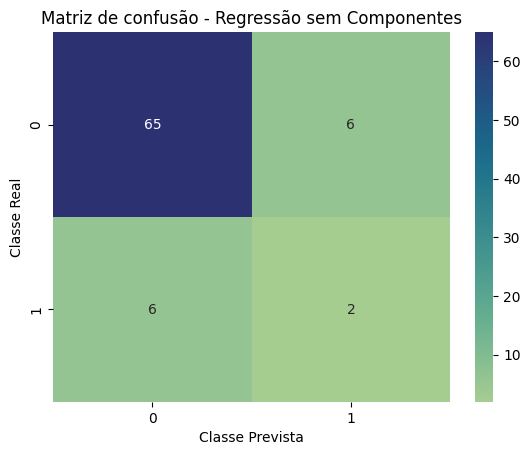

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        71
           1       0.25      0.25      0.25         8

    accuracy                           0.85        79
   macro avg       0.58      0.58      0.58        79
weighted avg       0.85      0.85      0.85        79

AUC sem Componentes: 0.5827464788732394
=== Stratified K-fold (sem componentes) ===
              precision    recall  f1-score   support

           0     0.9004    0.9576    0.9281       236
           1     0.0909    0.0385    0.0541        26

    accuracy                         0.8664       262
   macro avg     0.4957    0.4980    0.4911       262
weighted avg     0.8201    0.8664    0.8414       262



In [12]:
# Avaliação do modelo sem componentes
if all(col in X_train.columns for col in col_componentes) and all(col in X_test.columns for col in col_componentes):
    confusion_sem_componentes = confusion_matrix(y_test, y_pred_LR_sem_componentes)
    sns.heatmap(confusion_sem_componentes, annot=True, fmt='d', cmap='crest')
    plt.xlabel("Classe Prevista")
    plt.ylabel("Classe Real")
    plt.title("Matriz de confusão - Regressão sem Componentes")
    plt.show()

    print(classification_report(y_test, y_pred_LR_sem_componentes))
    auc_sem_componentes = roc_auc_score(y_test, y_pred_LR_sem_componentes)
    print("AUC sem Componentes:", auc_sem_componentes)

    print("=== Stratified K-fold (sem componentes) ===")
    print(classification_report(y, pred_cross_sem_componentes, digits=4))

Com base nos resultados obtidos, a utilização das variáveis componentes (WR_0, WD_0 e WAtotal_0) mostrou-se mais informativa do que a variável agregada WT_0, sendo portanto a opção preferencial neste contexto.

# 4.2) Comparação 2: IMC versus variáveis de base (Peso e Altura_cm)

In [13]:
# remover IMC dos dados de treino e teste
col_IMC = 'IMC'

if col_IMC in X_train.columns and col_IMC in X_test.columns:
    X_train_sem_imc = X_train.drop(columns=[col_IMC])
    X_test_sem_imc = X_test.drop(columns=[col_IMC])

    # Treinar modelo sem IMC
    clf_LR_sem_imc = LogisticRegression(random_state=42, max_iter=2000)
    clf_LR_sem_imc = clf_LR_sem_imc.fit(X_train_sem_imc, y_train)

    # Previsões
    y_pred_LR_sem_imc = clf_LR_sem_imc.predict(X_test_sem_imc)

    # Stratified K-fold (sem IMC)
    X_sem_imc_cv = X.drop(columns=[col_IMC])
    cv_sem_imc = sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pred_cross_sem_imc = cross_val_predict(
        LogisticRegression(random_state=42, max_iter=2000),
        X_sem_imc_cv,
        y,
        cv=cv_sem_imc
    )

c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please

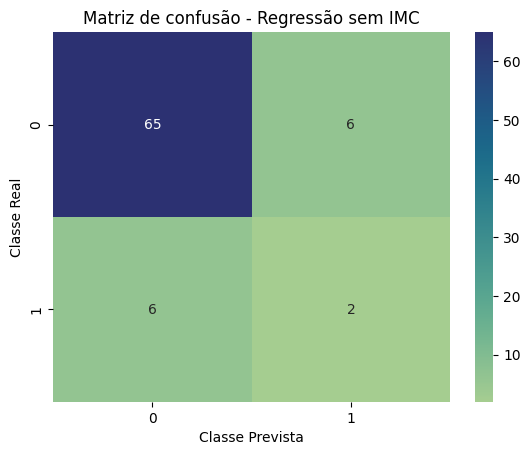

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        71
           1       0.25      0.25      0.25         8

    accuracy                           0.85        79
   macro avg       0.58      0.58      0.58        79
weighted avg       0.85      0.85      0.85        79

AUC sem IMC: 0.5827464788732394
=== Stratified K-fold (sem IMC) ===
              precision    recall  f1-score   support

           0     0.9109    0.9534    0.9317       236
           1     0.2667    0.1538    0.1951        26

    accuracy                         0.8740       262
   macro avg     0.5888    0.5536    0.5634       262
weighted avg     0.8470    0.8740    0.8586       262



In [14]:
# Avaliação do modelo sem IMC
if col_IMC in X_train.columns and col_IMC in X_test.columns:
    confusion_sem_imc = confusion_matrix(y_test, y_pred_LR_sem_imc)
    sns.heatmap(confusion_sem_imc, annot=True, fmt='d', cmap='crest')
    plt.xlabel("Classe Prevista")
    plt.ylabel("Classe Real")
    plt.title("Matriz de confusão - Regressão sem IMC")
    plt.show()

    print(classification_report(y_test, y_pred_LR_sem_imc))
    auc_sem_imc = roc_auc_score(y_test, y_pred_LR_sem_imc)
    print("AUC sem IMC:", auc_sem_imc)

    print("=== Stratified K-fold (sem IMC) ===")
    print(classification_report(y, pred_cross_sem_imc, digits=4))

In [15]:
# remover Peso e Altura_cm dos dados de treino e de teste
col_Peso = 'Peso'
col_Altura_cm = 'Altura_cm'
col_peso_altura = [col_Peso, col_Altura_cm]

if all(col in X_train.columns for col in col_peso_altura) and all(col in X_test.columns for col in col_peso_altura):
    X_train_sem_peso_altura = X_train.drop(columns=col_peso_altura)
    X_test_sem_peso_altura = X_test.drop(columns=col_peso_altura)

    # Treinar modelo sem Peso e Altura_cm
    clf_LR_sem_peso_altura = LogisticRegression(random_state=42, max_iter=2000)
    clf_LR_sem_peso_altura = clf_LR_sem_peso_altura.fit(X_train_sem_peso_altura, y_train)

    # Previsões
    y_pred_LR_sem_peso_altura = clf_LR_sem_peso_altura.predict(X_test_sem_peso_altura)

    # Stratified K-fold (sem Peso e Altura_cm)
    X_sem_peso_altura_cv = X.drop(columns=col_peso_altura)
    cv_sem_peso_altura = sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pred_cross_sem_peso_altura = cross_val_predict(
        LogisticRegression(random_state=42, max_iter=2000),
        X_sem_peso_altura_cv,
        y,
        cv=cv_sem_peso_altura
    )

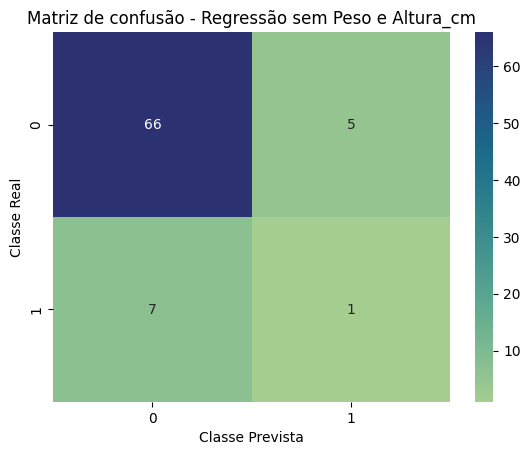

              precision    recall  f1-score   support

           0       0.90      0.93      0.92        71
           1       0.17      0.12      0.14         8

    accuracy                           0.85        79
   macro avg       0.54      0.53      0.53        79
weighted avg       0.83      0.85      0.84        79

AUC sem Peso e Altura_cm: 0.5272887323943662
=== Stratified K-fold (sem Peso e Altura_cm) ===
              precision    recall  f1-score   support

           0     0.9113    0.9576    0.9339       236
           1     0.2857    0.1538    0.2000        26

    accuracy                         0.8779       262
   macro avg     0.5985    0.5557    0.5669       262
weighted avg     0.8492    0.8779    0.8611       262



In [16]:
# Avaliação do modelo sem Peso e Altura_cm
if all(col in X_train.columns for col in col_peso_altura) and all(col in X_test.columns for col in col_peso_altura):
    confusion_sem_peso_altura = confusion_matrix(y_test, y_pred_LR_sem_peso_altura)
    sns.heatmap(confusion_sem_peso_altura, annot=True, fmt='d', cmap='crest')
    plt.xlabel("Classe Prevista")
    plt.ylabel("Classe Real")
    plt.title("Matriz de confusão - Regressão sem Peso e Altura_cm")
    plt.show()

    print(classification_report(y_test, y_pred_LR_sem_peso_altura))
    auc_sem_peso_altura = roc_auc_score(y_test, y_pred_LR_sem_peso_altura)
    print("AUC sem Peso e Altura_cm:", auc_sem_peso_altura)

    print("=== Stratified K-fold (sem Peso e Altura_cm) ===")
    print(classification_report(y, pred_cross_sem_peso_altura, digits=4))

Com base nos resultados obtidos, a utilização das variáveis Peso e Altura_cm mostrou-se mais informativa do que a variável calculada IMC, sendo portanto a opção preferencial neste contexto.


# 4.3)  Remoção simultânea de variaveis compostas para eliminar redundância

Embora a remoção isolada de cada variável composta possa melhorar algumas métricas, a remoção conjunta de ambas nem sempre se traduz em ganho de desempenho global.


In [17]:
# remover IMC e WT_0 dos dados de treino e teste
col_IMC = 'IMC'
col_wt0 = 'WT_0'
col_imc_wt0 = [col_IMC, col_wt0]

if all(col in X_train.columns for col in col_imc_wt0) and all(col in X_test.columns for col in col_imc_wt0):
    X_train_sem_imc_wt0 = X_train.drop(columns=col_imc_wt0)
    X_test_sem_imc_wt0 = X_test.drop(columns=col_imc_wt0)

    # Treinar modelo sem IMC e WT_0
    clf_LR_sem_imc_wt0 = LogisticRegression(random_state=42, max_iter=2000)
    clf_LR_sem_imc_wt0 = clf_LR_sem_imc_wt0.fit(X_train_sem_imc_wt0, y_train)

    # Previsões
    y_pred_LR_sem_imc_wt0 = clf_LR_sem_imc_wt0.predict(X_test_sem_imc_wt0)

    # Stratified K-fold (sem IMC e WT_0)
    X_sem_imc_wt0_cv = X.drop(columns=col_imc_wt0)
    cv_sem_imc_wt0 = sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pred_cross_sem_imc_wt0 = cross_val_predict(
        LogisticRegression(random_state=42, max_iter=2000),
        X_sem_imc_wt0_cv,
        y,
        cv=cv_sem_imc_wt0
    )

c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Eduardo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please

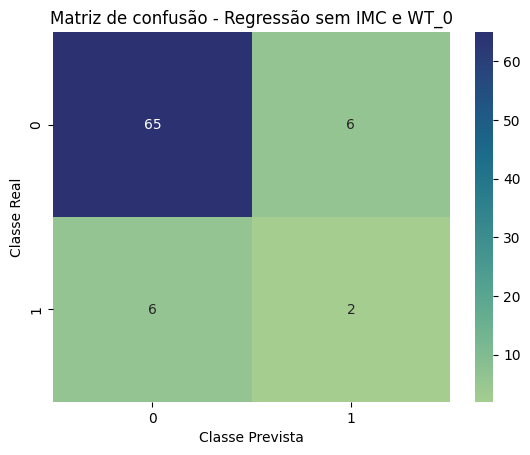

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        71
           1       0.25      0.25      0.25         8

    accuracy                           0.85        79
   macro avg       0.58      0.58      0.58        79
weighted avg       0.85      0.85      0.85        79

AUC sem IMC e WT_0: 0.5827464788732394
=== Stratified K-fold (sem IMC e WT_0) ===
              precision    recall  f1-score   support

           0     0.9109    0.9534    0.9317       236
           1     0.2667    0.1538    0.1951        26

    accuracy                         0.8740       262
   macro avg     0.5888    0.5536    0.5634       262
weighted avg     0.8470    0.8740    0.8586       262



In [18]:
# Avaliação do modelo sem IMC e WT_0
if all(col in X_train.columns for col in col_imc_wt0) and all(col in X_test.columns for col in col_imc_wt0):
    confusion_sem_imc_wt0 = confusion_matrix(y_test, y_pred_LR_sem_imc_wt0)
    sns.heatmap(confusion_sem_imc_wt0, annot=True, fmt='d', cmap='crest')
    plt.xlabel("Classe Prevista")
    plt.ylabel("Classe Real")
    plt.title("Matriz de confusão - Regressão sem IMC e WT_0")
    plt.show()

    print(classification_report(y_test, y_pred_LR_sem_imc_wt0))
    auc_sem_imc_wt0 = roc_auc_score(y_test, y_pred_LR_sem_imc_wt0)
    print("AUC sem IMC e WT_0:", auc_sem_imc_wt0)

    print("=== Stratified K-fold (sem IMC e WT_0) ===")
    print(classification_report(y, pred_cross_sem_imc_wt0, digits=4))

Com base nos testes de remoção e na afinação do modelo, conclui-se que, neste conjunto de dados, não compensa retirar nenhuma variável para fins de desempenho preditivo. De forma consistente, os cenários com remoções (incluindo variáveis derivadas como IMC e WT_0) não superaram o modelo com o conjunto completo, sobretudo nas métricas prioritárias de Precision e Recall. Assim, a decisão recomendada é manter todas as variáveis no modelo final, deixando eventuais exclusões apenas para casos em que a prioridade seja simplificação e interpretabilidade, e não maximização de performance.

# 6) Grid Search inicial
Nesta etapa procuramos os melhores hiperparâmetros da Regressão Logística sem assumir à partida que `class_weight='balanced'` é o melhor cenário.

Melhores parâmetros (Grid inicial): {'C': 1.0, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Melhor F1 (CV): 0.3488

Resultado CV (estilo matriz):


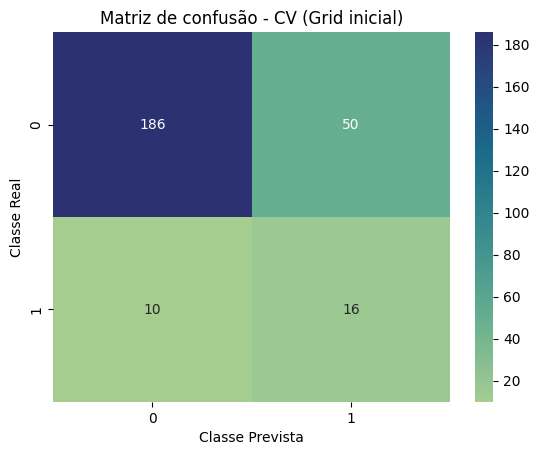

Precision classe 0: 0.9490
Precision classe 1: 0.2424
Recall classe 0: 0.7881
Recall classe 1: 0.6154
F1 classe 0: 0.8611
F1 classe 1: 0.3478
AUC-ROC: 0.7608


In [19]:
# 6.1) Grid Search inicial: solver, penalty, C e class_weight
X_modelagem = X.copy()

cv_grid = sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_rl = [
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1.0, 5.0, 10.0],
        'class_weight': [None, 'balanced', {0: 1, 1: 1.5}, {0: 1, 1: 2}]
    },
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1.0, 5.0, 10.0],
        'class_weight': [None, 'balanced', {0: 1, 1: 1.5}, {0: 1, 1: 2}]
    }
]

# Métricas padrão para todas as comparações de modelos:
# precision, recall e F1 por classe (0 e 1) + AUC-ROC
def calcular_metricas_modelo(y_true, y_pred, y_prob):
    precisao, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0
    )
    return {
        'Precision_classe_0': precisao[0],
        'Precision_classe_1': precisao[1],
        'Recall_classe_0': recall[0],
        'Recall_classe_1': recall[1],
        'F1_classe_0': f1[0],
        'F1_classe_1': f1[1],
        'AUC_ROC': roc_auc_score(y_true, y_prob)
    }

def mostrar_resultado_com_matriz(y_true, y_pred, y_prob, titulo):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='crest')
    plt.xlabel('Classe Prevista')
    plt.ylabel('Classe Real')
    plt.title(titulo)
    plt.show()

    m = calcular_metricas_modelo(y_true, y_pred, y_prob)
    print(f"Precision classe 0: {m['Precision_classe_0']:.4f}")
    print(f"Precision classe 1: {m['Precision_classe_1']:.4f}")
    print(f"Recall classe 0: {m['Recall_classe_0']:.4f}")
    print(f"Recall classe 1: {m['Recall_classe_1']:.4f}")
    print(f"F1 classe 0: {m['F1_classe_0']:.4f}")
    print(f"F1 classe 1: {m['F1_classe_1']:.4f}")
    print(f"AUC-ROC: {m['AUC_ROC']:.4f}")
    return m

modelo_grid = LogisticRegression(random_state=42, max_iter=10000)

grid_inicial = sk.model_selection.GridSearchCV(
    estimator=modelo_grid,
    param_grid=param_grid_rl,
    scoring='f1',
    cv=cv_grid,
    n_jobs=-1
)

grid_inicial.fit(X_modelagem, y)

melhor_modelo_inicial = grid_inicial.best_estimator_
print('Melhores parâmetros (Grid inicial):', grid_inicial.best_params_)
print('Melhor F1 (CV):', round(grid_inicial.best_score_, 4))

pred_cv_inicial = cross_val_predict(
    melhor_modelo_inicial,
    X_modelagem,
    y,
    cv=cv_grid
)
prob_cv_inicial = cross_val_predict(
    melhor_modelo_inicial,
    X_modelagem,
    y,
    cv=cv_grid,
    method='predict_proba'
)[:, 1]

print('\nResultado CV (estilo matriz):')
metricas_cv_inicial = mostrar_resultado_com_matriz(
    y,
    pred_cv_inicial,
    prob_cv_inicial,
    'Matriz de confusão - CV (Grid inicial)'
)

Resultado holdout (estilo matriz):


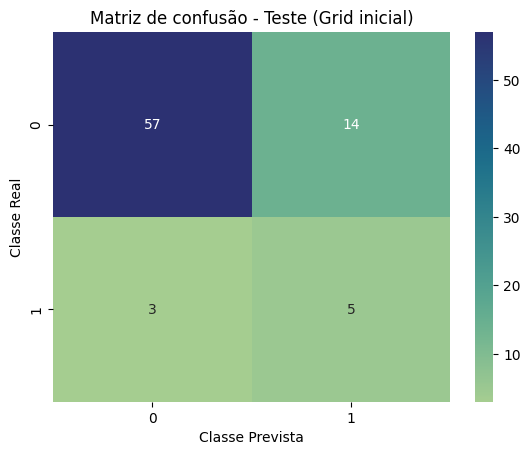

Precision classe 0: 0.9500
Precision classe 1: 0.2632
Recall classe 0: 0.8028
Recall classe 1: 0.6250
F1 classe 0: 0.8702
F1 classe 1: 0.3704
AUC-ROC: 0.7570


In [20]:
# 6.2) Avaliação holdout do melhor modelo do Grid inicial
X_train_grid, X_test_grid, y_train_grid, y_test_grid = train_test_split(
    X_modelagem,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

melhor_modelo_inicial.fit(X_train_grid, y_train_grid)
y_pred_grid_teste = melhor_modelo_inicial.predict(X_test_grid)
y_prob_grid_teste = melhor_modelo_inicial.predict_proba(X_test_grid)[:, 1]

print('Resultado holdout (estilo matriz):')
metricas_holdout_inicial = mostrar_resultado_com_matriz(
    y_test_grid,
    y_pred_grid_teste,
    y_prob_grid_teste,
    'Matriz de confusão - Teste (Grid inicial)'
)

# 7) Teste de StandardScaler após o Grid inicial
Com os melhores hiperparâmetros encontrados no Grid inicial, testamos se adicionar `StandardScaler` melhora o desempenho.

In [21]:
# 7.1) Comparação CV: sem scaler vs com scaler (mesmos hiperparâmetros)
params_base = grid_inicial.best_params_.copy()

modelo_sem_scaler = Pipeline([
    ('modelo', LogisticRegression(
        random_state=42,
        max_iter=10000,
        solver=params_base['solver'],
        penalty=params_base['penalty'],
        C=params_base['C'],
        class_weight=params_base['class_weight']
    ))
])

modelo_com_scaler = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(
        random_state=42,
        max_iter=10000,
        solver=params_base['solver'],
        penalty=params_base['penalty'],
        C=params_base['C'],
        class_weight=params_base['class_weight']
    ))
])

cv_scaler = sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def resumo_cv_modelo(nome, modelo):
    pred_cv = cross_val_predict(modelo, X_modelagem, y, cv=cv_scaler)
    prob_cv = cross_val_predict(modelo, X_modelagem, y, cv=cv_scaler, method='predict_proba')[:, 1]
    metricas = calcular_metricas_modelo(y, pred_cv, prob_cv)
    return {
        'Cenario': nome,
        'Precision_classe_0_cv': metricas['Precision_classe_0'],
        'Precision_classe_1_cv': metricas['Precision_classe_1'],
        'Recall_classe_0_cv': metricas['Recall_classe_0'],
        'Recall_classe_1_cv': metricas['Recall_classe_1'],
        'F1_classe_0_cv': metricas['F1_classe_0'],
        'F1_classe_1_cv': metricas['F1_classe_1'],
        'AUC_ROC_cv': metricas['AUC_ROC']
    }

linha_sem_scaler = resumo_cv_modelo('Sem scaler', modelo_sem_scaler)
linha_com_scaler = resumo_cv_modelo('Com scaler', modelo_com_scaler)

resumo_scaler_cv = pd.DataFrame([linha_sem_scaler, linha_com_scaler]).sort_values(
    by=['F1_classe_1_cv', 'Recall_classe_1_cv', 'AUC_ROC_cv'],
    ascending=False
).reset_index(drop=True)

print('=== Comparação CV (mesmos hiperparâmetros) ===')
print(resumo_scaler_cv.round(4))

usar_scaler_final = resumo_scaler_cv.iloc[0]['Cenario'] == 'Com scaler'
melhor_modelo_pos_scaler = modelo_com_scaler if usar_scaler_final else modelo_sem_scaler
print('\nArquitetura escolhida para as próximas afinações:', resumo_scaler_cv.iloc[0]['Cenario'])

=== Comparação CV (mesmos hiperparâmetros) ===
      Cenario  Precision_classe_0_cv  Precision_classe_1_cv  \
0  Sem scaler                 0.9490                 0.2424   
1  Com scaler                 0.9485                 0.2353   

   Recall_classe_0_cv  Recall_classe_1_cv  F1_classe_0_cv  F1_classe_1_cv  \
0              0.7881              0.6154          0.8611          0.3478   
1              0.7797              0.6154          0.8558          0.3404   

   AUC_ROC_cv  
0      0.7608  
1      0.7575  

Arquitetura escolhida para as próximas afinações: Sem scaler


Resultado holdout da arquitetura escolhida (estilo matriz):


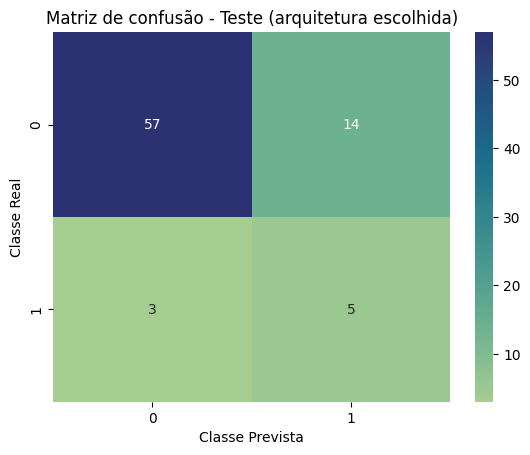

Precision classe 0: 0.9500
Precision classe 1: 0.2632
Recall classe 0: 0.8028
Recall classe 1: 0.6250
F1 classe 0: 0.8702
F1 classe 1: 0.3704
AUC-ROC: 0.7570


In [22]:
# 7.2) Avaliação holdout da arquitetura escolhida (com/sem scaler)
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_modelagem,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

melhor_modelo_pos_scaler.fit(X_train_final, y_train_final)
y_pred_final = melhor_modelo_pos_scaler.predict(X_test_final)
y_prob_final = melhor_modelo_pos_scaler.predict_proba(X_test_final)[:, 1]

print('Resultado holdout da arquitetura escolhida (estilo matriz):')
metricas_holdout_arquitetura = mostrar_resultado_com_matriz(
    y_test_final,
    y_pred_final,
    y_prob_final,
    'Matriz de confusão - Teste (arquitetura escolhida)'
)

# 8) Afinação de threshold para reduzir falsos positivos
Com a arquitetura escolhida na secção anterior, ajustamos o limiar de decisão para controlar melhor o compromisso entre precision e recall.

In [23]:
# 8.1) Sweep de threshold
# Reaproveitar o split final para comparar de forma consistente
melhor_modelo_pos_scaler.fit(X_train_final, y_train_final)
y_prob_thr = melhor_modelo_pos_scaler.predict_proba(X_test_final)[:, 1]

thresholds = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
linhas_thr = []

for thr in thresholds:
    y_pred_thr_tmp = (y_prob_thr >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_final, y_pred_thr_tmp).ravel()
    metricas_thr = calcular_metricas_modelo(y_test_final, y_pred_thr_tmp, y_prob_thr)

    linhas_thr.append({
        'threshold': thr,
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'TP': int(tp),
        'Precision_classe_0': metricas_thr['Precision_classe_0'],
        'Precision_classe_1': metricas_thr['Precision_classe_1'],
        'Recall_classe_0': metricas_thr['Recall_classe_0'],
        'Recall_classe_1': metricas_thr['Recall_classe_1'],
        'F1_classe_0': metricas_thr['F1_classe_0'],
        'F1_classe_1': metricas_thr['F1_classe_1'],
        'AUC_ROC': metricas_thr['AUC_ROC']
    })

resumo_threshold = pd.DataFrame(linhas_thr)
print('=== Tabela de threshold tuning (métricas por classe + AUC-ROC) ===')
print(resumo_threshold.round(4))

linha_base = resumo_threshold[resumo_threshold['threshold'] == 0.50].iloc[0]
precision_1_base = float(linha_base['Precision_classe_1'])

candidatos = resumo_threshold[
    resumo_threshold['Precision_classe_1'] >= precision_1_base
].copy()

if len(candidatos) == 0:
    melhor_thr = 0.50
else:
    candidatos = candidatos.sort_values(
        by=['FP', 'F1_classe_1', 'Recall_classe_1'],
        ascending=[True, False, False]
    )
    melhor_thr = float(candidatos.iloc[0]['threshold'])

print(f'\nThreshold recomendado: {melhor_thr:.2f}')

y_pred_recomendado = (y_prob_thr >= melhor_thr).astype(int)
cm_thr = confusion_matrix(y_test_final, y_pred_recomendado)

linha_recomendada = resumo_threshold[resumo_threshold['threshold'] == melhor_thr].iloc[0]
comparacao_threshold = pd.DataFrame([
    {
        'Cenario': 'Threshold 0.50 (baseline)',
        'Threshold': 0.50,
        'FP': int(linha_base['FP']),
        'Precision_classe_0': float(linha_base['Precision_classe_0']),
        'Precision_classe_1': float(linha_base['Precision_classe_1']),
        'Recall_classe_0': float(linha_base['Recall_classe_0']),
        'Recall_classe_1': float(linha_base['Recall_classe_1']),
        'F1_classe_0': float(linha_base['F1_classe_0']),
        'F1_classe_1': float(linha_base['F1_classe_1']),
        'AUC_ROC': float(linha_base['AUC_ROC'])
    },
    {
        'Cenario': 'Threshold recomendado',
        'Threshold': melhor_thr,
        'FP': int(linha_recomendada['FP']),
        'Precision_classe_0': float(linha_recomendada['Precision_classe_0']),
        'Precision_classe_1': float(linha_recomendada['Precision_classe_1']),
        'Recall_classe_0': float(linha_recomendada['Recall_classe_0']),
        'Recall_classe_1': float(linha_recomendada['Recall_classe_1']),
        'F1_classe_0': float(linha_recomendada['F1_classe_0']),
        'F1_classe_1': float(linha_recomendada['F1_classe_1']),
        'AUC_ROC': float(linha_recomendada['AUC_ROC'])
    }
])

=== Tabela de threshold tuning (métricas por classe + AUC-ROC) ===
   threshold  TN  FP  FN  TP  Precision_classe_0  Precision_classe_1  \
0       0.40  53  18   2   6              0.9636              0.2500   
1       0.45  55  16   2   6              0.9649              0.2727   
2       0.50  57  14   3   5              0.9500              0.2632   
3       0.55  59  12   3   5              0.9516              0.2941   
4       0.60  59  12   3   5              0.9516              0.2941   
5       0.65  63   8   3   5              0.9545              0.3846   
6       0.70  63   8   3   5              0.9545              0.3846   

   Recall_classe_0  Recall_classe_1  F1_classe_0  F1_classe_1  AUC_ROC  
0           0.7465            0.750       0.8413       0.3750    0.757  
1           0.7746            0.750       0.8594       0.4000    0.757  
2           0.8028            0.625       0.8702       0.3704    0.757  
3           0.8310            0.625       0.8872       0.4000   

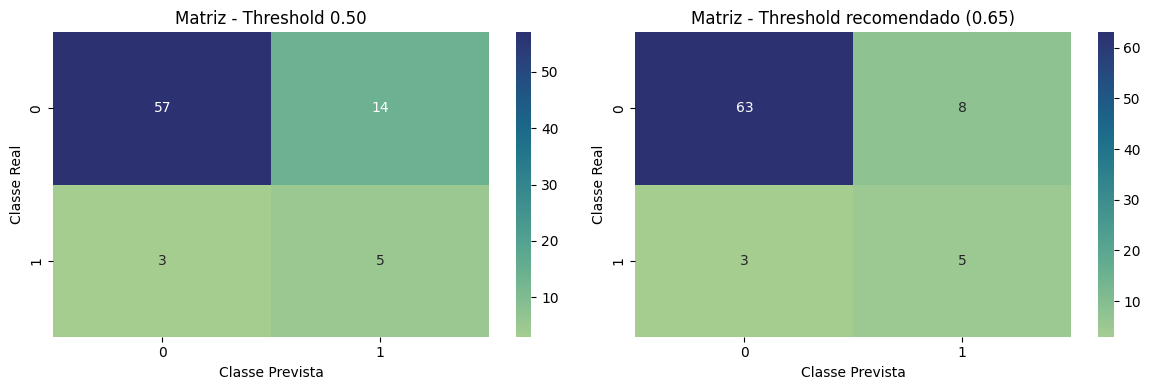

=== Threshold 0.50 ===
Precision classe 0: 0.9500
Precision classe 1: 0.2632
Recall classe 0: 0.8028
Recall classe 1: 0.6250
F1 classe 0: 0.8702
F1 classe 1: 0.3704
AUC-ROC: 0.7570

=== Threshold recomendado ===
Precision classe 0: 0.9545
Precision classe 1: 0.3846
Recall classe 0: 0.8873
Recall classe 1: 0.6250
F1 classe 0: 0.9197
F1 classe 1: 0.4762
AUC-ROC: 0.7570


In [24]:
# 8.2) Avaliação final do threshold recomendado (estilo matriz)
y_pred_base = (y_prob_thr >= 0.50).astype(int)
cm_base = confusion_matrix(y_test_final, y_pred_base)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='crest')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.title('Matriz - Threshold 0.50')

plt.subplot(1, 2, 2)
sns.heatmap(cm_thr, annot=True, fmt='d', cmap='crest')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.title(f'Matriz - Threshold recomendado ({melhor_thr:.2f})')
plt.tight_layout()
plt.show()

metricas_base = calcular_metricas_modelo(y_test_final, y_pred_base, y_prob_thr)
metricas_recomendado = calcular_metricas_modelo(y_test_final, y_pred_recomendado, y_prob_thr)

print('=== Threshold 0.50 ===')
print(f"Precision classe 0: {metricas_base['Precision_classe_0']:.4f}")
print(f"Precision classe 1: {metricas_base['Precision_classe_1']:.4f}")
print(f"Recall classe 0: {metricas_base['Recall_classe_0']:.4f}")
print(f"Recall classe 1: {metricas_base['Recall_classe_1']:.4f}")
print(f"F1 classe 0: {metricas_base['F1_classe_0']:.4f}")
print(f"F1 classe 1: {metricas_base['F1_classe_1']:.4f}")
print(f"AUC-ROC: {metricas_base['AUC_ROC']:.4f}")

print('\n=== Threshold recomendado ===')
print(f"Precision classe 0: {metricas_recomendado['Precision_classe_0']:.4f}")
print(f"Precision classe 1: {metricas_recomendado['Precision_classe_1']:.4f}")
print(f"Recall classe 0: {metricas_recomendado['Recall_classe_0']:.4f}")
print(f"Recall classe 1: {metricas_recomendado['Recall_classe_1']:.4f}")
print(f"F1 classe 0: {metricas_recomendado['F1_classe_0']:.4f}")
print(f"F1 classe 1: {metricas_recomendado['F1_classe_1']:.4f}")
print(f"AUC-ROC: {metricas_recomendado['AUC_ROC']:.4f}")

# 9) Afinação adicional de class_weight
Depois de escolher a arquitetura (com/sem scaler), fazemos uma afinação final de `class_weight` nessa mesma arquitetura.

In [25]:
# 9.1) Grid final de class_weight na arquitetura escolhida
params_base = grid_inicial.best_params_.copy()

if usar_scaler_final:
    pipe_cw = Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', LogisticRegression(
            random_state=42,
            max_iter=10000,
            solver=params_base['solver'],
            penalty=params_base['penalty'],
            C=params_base['C']
        ))
    ])
else:
    pipe_cw = Pipeline([
        ('modelo', LogisticRegression(
            random_state=42,
            max_iter=10000,
            solver=params_base['solver'],
            penalty=params_base['penalty'],
            C=params_base['C']
        ))
    ])

param_grid_cw = {
    'modelo__class_weight': [
        None,
        'balanced',
        {0: 1, 1: 1.25},
        {0: 1, 1: 1.5},
        {0: 1, 1: 2},
        {0: 1, 1: 3}
    ]
}

cv_cw = sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_cw = GridSearchCV(
    estimator=pipe_cw,
    param_grid=param_grid_cw,
    scoring='f1',
    cv=cv_cw,
    n_jobs=-1
)

grid_cw.fit(X_modelagem, y)
melhor_modelo_cw = grid_cw.best_estimator_

print('Melhor class_weight (grid final):', grid_cw.best_params_['modelo__class_weight'])
print('Melhor F1 (CV):', round(grid_cw.best_score_, 4))

pred_cv_cw = cross_val_predict(melhor_modelo_cw, X_modelagem, y, cv=cv_cw)
prob_cv_cw = cross_val_predict(melhor_modelo_cw, X_modelagem, y, cv=cv_cw, method='predict_proba')[:, 1]

metricas_cv_cw = calcular_metricas_modelo(y, pred_cv_cw, prob_cv_cw)
resumo_cv_cw = pd.DataFrame([
    {
        'Cenario': 'Melhor class_weight final (CV)',
        'Precision_classe_0_cv': metricas_cv_cw['Precision_classe_0'],
        'Precision_classe_1_cv': metricas_cv_cw['Precision_classe_1'],
        'Recall_classe_0_cv': metricas_cv_cw['Recall_classe_0'],
        'Recall_classe_1_cv': metricas_cv_cw['Recall_classe_1'],
        'F1_classe_0_cv': metricas_cv_cw['F1_classe_0'],
        'F1_classe_1_cv': metricas_cv_cw['F1_classe_1'],
        'AUC_ROC_cv': metricas_cv_cw['AUC_ROC']
    }
])

print('\nResumo CV - melhor class_weight final (métricas por classe + AUC-ROC):')
print(resumo_cv_cw.round(4))

Melhor class_weight (grid final): balanced
Melhor F1 (CV): 0.3488

Resumo CV - melhor class_weight final (métricas por classe + AUC-ROC):
                          Cenario  Precision_classe_0_cv  \
0  Melhor class_weight final (CV)                  0.949   

   Precision_classe_1_cv  Recall_classe_0_cv  Recall_classe_1_cv  \
0                 0.2424              0.7881              0.6154   

   F1_classe_0_cv  F1_classe_1_cv  AUC_ROC_cv  
0          0.8611          0.3478      0.7608  


Resultado holdout final (estilo matriz):


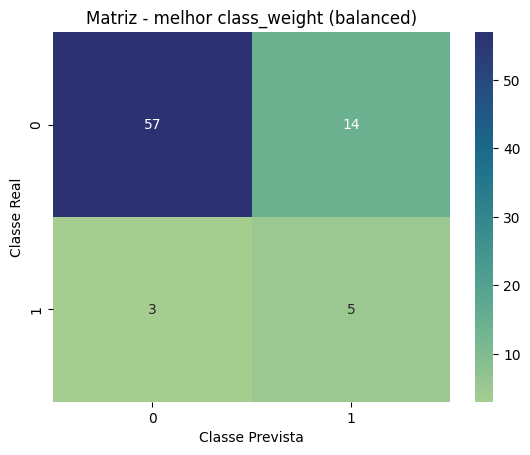

Precision classe 0: 0.9500
Precision classe 1: 0.2632
Recall classe 0: 0.8028
Recall classe 1: 0.6250
F1 classe 0: 0.8702
F1 classe 1: 0.3704
AUC-ROC: 0.7570

Resumo final do modelo escolhido:
Solver: liblinear
Penalty: l1
C: 1.0
Class_weight: balanced
Scaler: Sem scaler
Threshold recomendado: 0.65


In [26]:
# 9.2) Avaliação holdout do melhor class_weight final
melhor_modelo_cw.fit(X_train_final, y_train_final)
y_pred_cw = melhor_modelo_cw.predict(X_test_final)
y_prob_cw = melhor_modelo_cw.predict_proba(X_test_final)[:, 1]

print('Resultado holdout final (estilo matriz):')
metricas_holdout_cw = mostrar_resultado_com_matriz(
    y_test_final,
    y_pred_cw,
    y_prob_cw,
    f"Matriz - melhor class_weight ({grid_cw.best_params_['modelo__class_weight']})"
)

print('\nResumo final do modelo escolhido:')
print('Solver:', grid_inicial.best_params_['solver'])
print('Penalty:', grid_inicial.best_params_['penalty'])
print('C:', grid_inicial.best_params_['C'])
print('Class_weight:', grid_cw.best_params_['modelo__class_weight'])
print('Scaler:', 'Com scaler' if usar_scaler_final else 'Sem scaler')
print('Threshold recomendado:', round(melhor_thr, 2))

=== Comparação simples de matrizes de confusão (teste) ===
                          Cenario  TN  FP  FN  TP
0                    Grid inicial  57  14   3   5
1           Arquitetura escolhida  57  14   3   5
2    Threshold recomendado (0.65)  63   8   3   5
3  Melhor class_weight (balanced)  57  14   3   5

=== Matrizes de confusão (gráfico) ===


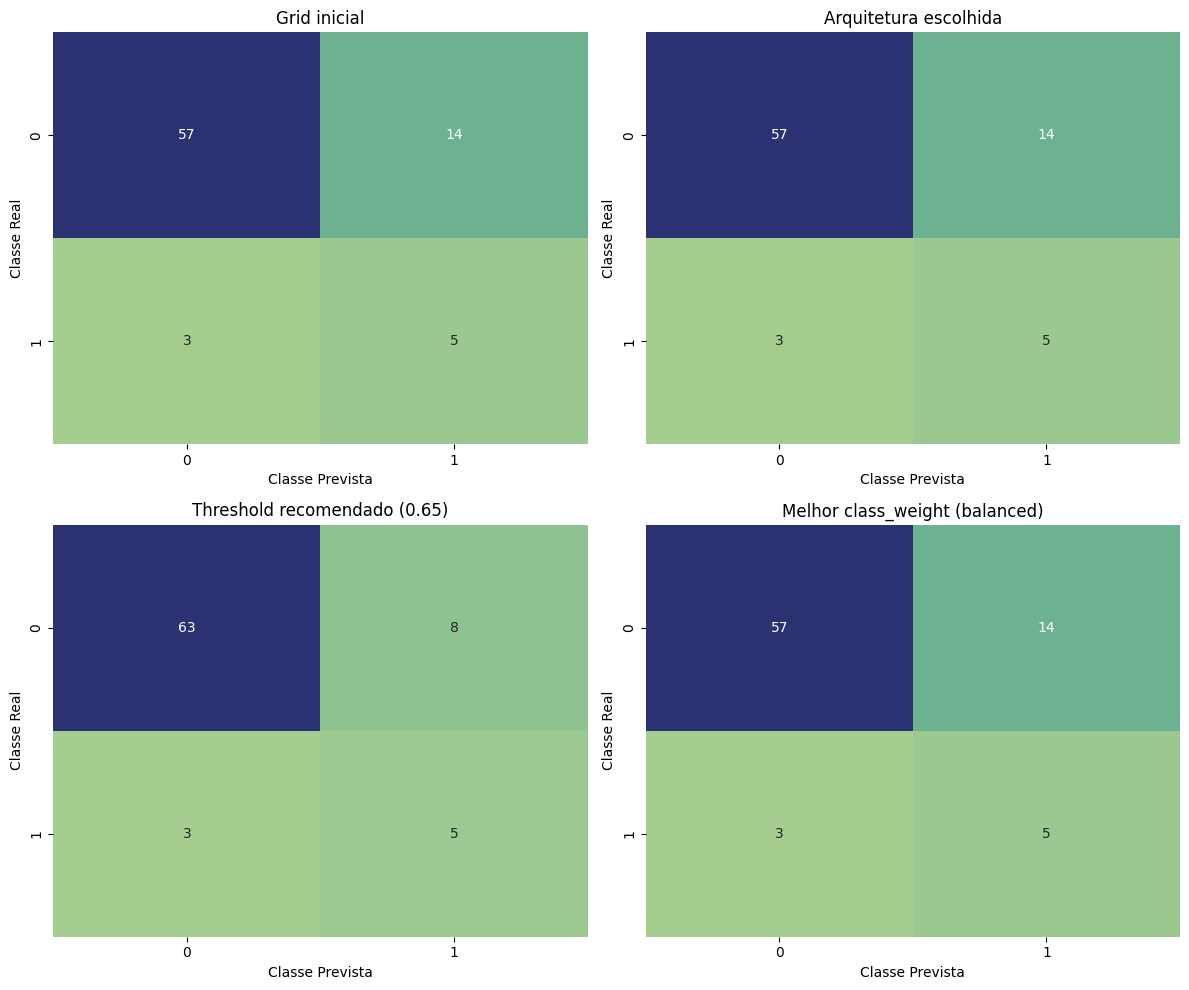


=== Métricas por cenário (mesmo formato do documento) ===
                          Cenario  Precision_classe_0  Precision_classe_1  \
0                    Grid inicial              0.9500              0.2632   
1           Arquitetura escolhida              0.9500              0.2632   
2    Threshold recomendado (0.65)              0.9545              0.3846   
3  Melhor class_weight (balanced)              0.9500              0.2632   

   Recall_classe_0  Recall_classe_1  F1_classe_0  F1_classe_1  AUC_ROC  
0           0.8028            0.625       0.8702       0.3704    0.757  
1           0.8028            0.625       0.8702       0.3704    0.757  
2           0.8873            0.625       0.9197       0.4762    0.757  
3           0.8028            0.625       0.8702       0.3704    0.757  

=== Grid inicial ===
Precision classe 0: 0.9500
Precision classe 1: 0.2632
Recall classe 0: 0.8028
Recall classe 1: 0.6250
F1 classe 0: 0.8702
F1 classe 1: 0.3704
AUC-ROC: 0.7570

=== Arqui

In [27]:
# 10.1) Comparação gráfica e métricas finais no teste
def linha_matriz_teste(cenario, y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Cenario': cenario,
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'TP': int(tp)
    }

cenarios_teste = [
    ('Grid inicial', y_test_grid, y_pred_grid_teste, y_prob_grid_teste),
    ('Arquitetura escolhida', y_test_final, y_pred_final, y_prob_final),
    (f'Threshold recomendado ({melhor_thr:.2f})', y_test_final, y_pred_recomendado, y_prob_thr),
    (f'Melhor class_weight ({grid_cw.best_params_["modelo__class_weight"]})', y_test_final, y_pred_cw, y_prob_cw)
 ]

comparacao_matriz_teste = pd.DataFrame([
    linha_matriz_teste(nome, y_true, y_pred)
    for nome, y_true, y_pred, _ in cenarios_teste
])

print('=== Comparação simples de matrizes de confusão (teste) ===')
print(comparacao_matriz_teste)

print('\n=== Matrizes de confusão (gráfico) ===')
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

comparacao_metricas_teste = []
for i, (nome, y_true, y_pred, y_prob) in enumerate(cenarios_teste):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='crest', ax=axes[i], cbar=False)
    axes[i].set_title(nome)
    axes[i].set_xlabel('Classe Prevista')
    axes[i].set_ylabel('Classe Real')

    metricas_tmp = calcular_metricas_modelo(y_true, y_pred, y_prob)
    comparacao_metricas_teste.append({
        'Cenario': nome,
        'Precision_classe_0': metricas_tmp['Precision_classe_0'],
        'Precision_classe_1': metricas_tmp['Precision_classe_1'],
        'Recall_classe_0': metricas_tmp['Recall_classe_0'],
        'Recall_classe_1': metricas_tmp['Recall_classe_1'],
        'F1_classe_0': metricas_tmp['F1_classe_0'],
        'F1_classe_1': metricas_tmp['F1_classe_1'],
        'AUC_ROC': metricas_tmp['AUC_ROC']
    })

plt.tight_layout()
plt.show()

comparacao_metricas_teste = pd.DataFrame(comparacao_metricas_teste)
print('\n=== Métricas por cenário (mesmo formato do documento) ===')
print(comparacao_metricas_teste.round(4))

for _, linha in comparacao_metricas_teste.iterrows():
    print(f"\n=== {linha['Cenario']} ===")
    print(f"Precision classe 0: {linha['Precision_classe_0']:.4f}")
    print(f"Precision classe 1: {linha['Precision_classe_1']:.4f}")
    print(f"Recall classe 0: {linha['Recall_classe_0']:.4f}")
    print(f"Recall classe 1: {linha['Recall_classe_1']:.4f}")
    print(f"F1 classe 0: {linha['F1_classe_0']:.4f}")
    print(f"F1 classe 1: {linha['F1_classe_1']:.4f}")
    print(f"AUC-ROC: {linha['AUC_ROC']:.4f}")

# 10) Comparação final no teste: matriz + gráficos + métricas
Resumo final com tabela `TN/FP/FN/TP`, representação gráfica das matrizes de confusão e métricas por classe no mesmo formato das secções anteriores.